# RFUAV Experiment 4 — Kaggle Version

This notebook trains **ResNet18** on the Kaggle **Noisy Drone RF Signal Classification** dataset.

Before running:

1. Open the notebook on Kaggle.
2. Click **Add Input**.
3. Add the dataset: `sgluege/noisy-drone-rf-signal-classification`.
4. In notebook settings, set **Accelerator → GPU**.

The notebook uses:

```text
/kaggle/input/    # read-only dataset files
/kaggle/working/  # saved models, plots, CSV results
```

The model input is:

```text
x_spec: [number_of_samples, 2, 128, 128]
```


## 1. Check GPU, RAM, and disk

Run this first to confirm whether Kaggle has a GPU attached and enough RAM/disk space.

In [1]:
import os
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. On Kaggle: Settings → Accelerator → GPU.")

print("\nRAM:")
!free -h

print("\nDisk:")
!df -h /kaggle/working


CUDA available: True
GPU: Tesla T4

RAM:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.0Gi        27Gi       1.0Mi       3.3Gi        29Gi
Swap:             0B          0B          0B

Disk:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  232K   20G   1% /kaggle/working


## 2. Locate the Kaggle dataset

This replaces the old Colab/Kaggle-API download cells. On Kaggle, use **Add Input** instead of downloading the dataset inside the notebook.

In [2]:
import os
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Find dataset.pt automatically so the notebook still works if Kaggle changes the mounted folder name.
candidates = list(KAGGLE_INPUT.rglob("dataset.pt"))
if not candidates:
    raise FileNotFoundError(
        "Could not find dataset.pt under /kaggle/input. "
        "Click Add Input and attach sgluege/noisy-drone-rf-signal-classification first."
    )

DATA_PATH = candidates[0]
DATA_DIR = DATA_PATH.parent

class_stats_path = DATA_DIR / "class_stats.csv"
snr_stats_path = DATA_DIR / "SNR_stats.csv"

print("DATA_DIR:", DATA_DIR)
print("DATA_PATH:", DATA_PATH)
print("File size GB:", DATA_PATH.stat().st_size / 1024**3)
print("SAVE_DIR:", SAVE_DIR)

print("\nFiles in DATA_DIR:")
for p in sorted(DATA_DIR.iterdir()):
    print("-", p.name)


DATA_DIR: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification
DATA_PATH: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification/dataset.pt
File size GB: 24.099373045377433
SAVE_DIR: /kaggle/working/noisy_drone_resnet18_spec_balanced

Files in DATA_DIR:
- SNR_stats.csv
- class_stats.csv
- dataset.pt


## 3. Inspect class and SNR statistics

This shows the class imbalance and SNR distribution.


In [3]:
import pandas as pd

class_stats = pd.read_csv(class_stats_path)
snr_stats = pd.read_csv(snr_stats_path)

print("Class stats:")
display(class_stats)

print("SNR stats:")
display(snr_stats)


Class stats:


,Unnamed: 0,class,class_int,count
0,0,DJI,0,2194
1,1,FutabaT14,1,6938
2,2,FutabaT7,2,3661
3,3,Graupner,3,6481
4,4,Noise,4,52552
5,5,Taranis,5,16546
6,6,Turnigy,6,10333


SNR stats:


,Unnamed: 0,SNR,count
0,0,-20,3792
1,1,-18,3795
2,2,-16,3796
3,3,-14,3796
4,4,-12,3797
5,5,-10,3796
6,6,-8,3795
7,7,-6,3795
8,8,-4,3798
9,9,-2,3798


## 4. Safely load `dataset.pt` with memory mapping

`dataset.pt` is large, so normal `torch.load()` can use too much RAM. This notebook uses `mmap=True` to avoid loading everything into memory at once.

In [4]:
import torch

print("Before loading:")
!free -h

data = torch.load(
    DATA_PATH,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully with mmap")
print("Type:", type(data))

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

print("After loading:")
!free -h


Before loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.1Gi        26Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.1Gi        26Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B


## 5. Create a balanced 7-class subset

The full dataset is imbalanced because the `Noise` class is much larger than the smallest class.

For a fair first experiment, use:

- 1700 training samples per class
- 400 validation samples per class
- 7 classes total

In [5]:
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class_names = [
    "DJI",
    "FutabaT14",
    "FutabaT7",
    "Graupner",
    "Noise",
    "Taranis",
    "Turnigy"
]

y = data["y"]

# Set QUICK_TEST = True for a short pipeline test before using GPU quota on a full run.
QUICK_TEST = False

if QUICK_TEST:
    train_per_class = 300
    valid_per_class = 100
else:
    train_per_class = 1700
    valid_per_class = 400

train_indices = []
valid_indices = []

for cls, name in enumerate(class_names):
    cls_indices = torch.where(y == cls)[0].cpu().numpy()
    np.random.shuffle(cls_indices)

    needed = train_per_class + valid_per_class
    if len(cls_indices) < needed:
        raise ValueError(f"Class {name} has only {len(cls_indices)} samples, but {needed} are needed.")

    train_indices.extend(cls_indices[:train_per_class])
    valid_indices.extend(cls_indices[train_per_class:train_per_class + valid_per_class])

train_indices = np.array(train_indices)
valid_indices = np.array(valid_indices)

np.random.shuffle(train_indices)
np.random.shuffle(valid_indices)

print("Train samples:", len(train_indices))
print("Valid samples:", len(valid_indices))

for cls, name in enumerate(class_names):
    train_count = int((y[train_indices] == cls).sum().item())
    valid_count = int((y[valid_indices] == cls).sum().item())
    print(f"{name}: train={train_count}, valid={valid_count}")


Train samples: 11900
Valid samples: 2800
DJI: train=1700, valid=400
FutabaT14: train=1700, valid=400
FutabaT7: train=1700, valid=400
Graupner: train=1700, valid=400
Noise: train=1700, valid=400
Taranis: train=1700, valid=400
Turnigy: train=1700, valid=400


## 6. Build a PyTorch Dataset and DataLoader for `x_spec`

`x_spec` has shape:

```text
[number_of_samples, 2, 128, 128]
```

So the CNN input channel count must be `2`.


In [6]:
from torch.utils.data import Dataset, DataLoader

class NoisyDroneSpecDataset(Dataset):
    def __init__(self, data, indices):
        self.x_spec = data["x_spec"]
        self.y = data["y"]
        self.snr = data["snr"]
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]   # [2, 128, 128]
        label = self.y[real_idx]
        snr = self.snr[real_idx]
        return x, label, snr

batch_size = 64
num_workers = 0  # Safer for Kaggle + memory-mapped tensors
pin_memory = torch.cuda.is_available()

train_dataset = NoisyDroneSpecDataset(data, train_indices)
valid_dataset = NoisyDroneSpecDataset(data, valid_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_batch, y_batch, snr_batch = next(iter(train_loader))
print("x batch:", x_batch.shape)
print("y batch:", y_batch.shape)
print("snr batch:", snr_batch.shape)
print("x dtype:", x_batch.dtype)
print("y dtype:", y_batch.dtype)
print("snr dtype:", snr_batch.dtype)


x batch: torch.Size([64, 2, 128, 128])
y batch: torch.Size([64])
snr batch: torch.Size([64])
x dtype: torch.float32
y dtype: torch.int64
snr dtype: torch.int32


## 7. Define ResNet18 for 2-channel RF spectrograms

Normal ResNet18 expects RGB images with shape:

```text
[batch, 3, height, width]
```

This dataset uses RF spectrogram tensors with shape:

```text
[batch, 2, 128, 128]
```

So we modify the first convolution layer to accept 2 input channels and change the final fully connected layer to output 7 classes.

For this RF dataset, we use `weights=None` because ImageNet pretrained weights are designed for natural RGB images, not 2-channel RF spectrograms.


In [7]:
import torch.nn as nn
from torchvision import models

class ResNet18RFSpec(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Start with a standard ResNet18 architecture.
        # weights=None avoids RGB ImageNet pretrained weights.
        self.model = models.resnet18(weights=None)

        # Original ResNet18 first layer expects 3-channel RGB images.
        # Our RF spectrogram tensors have 2 channels, so change 3 -> 2.
        self.model.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # Replace the final classifier for 7 drone/noise classes.
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# Quick shape test before training.
model_test = ResNet18RFSpec(num_classes=7)
with torch.no_grad():
    out = model_test(x_batch[:2])
print("Test output shape:", out.shape)


Test output shape: torch.Size([2, 7])


## 8. Set Kaggle output folder for saving results

Kaggle outputs should be saved in `/kaggle/working/` so they appear in the notebook Output section.


In [8]:
SAVE_DIR = Path("/kaggle/working/noisy_drone_resnet18_spec_balanced")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("Save directory:", SAVE_DIR)


Save directory: /kaggle/working/noisy_drone_resnet18_spec_balanced


## 9. Train ResNet18

This trains ResNet18 on the balanced spectrogram subset and saves:

- `best.pt`
- `last.pt`
- `history.csv`

Start with `batch_size = 64`. If Kaggle gives a CUDA out-of-memory error, go back to the DataLoader cell and reduce `batch_size` to `32`.


In [9]:
import torch.optim as optim
from tqdm import tqdm
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ResNet18RFSpec(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 2 if QUICK_TEST else 25
history = []
best_acc = 0.0

for epoch in range(epochs):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{epochs}")

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for x, labels, snrs in tqdm(train_loader, desc="Training"):
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    valid_loss = 0.0
    valid_correct = 0
    valid_total = 0

    with torch.no_grad():
        for x, labels, snrs in tqdm(valid_loader, desc="Validation"):
            x = x.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, labels)

            valid_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            valid_correct += (preds == labels).sum().item()
            valid_total += labels.size(0)

    valid_loss /= valid_total
    valid_acc = valid_correct / valid_total

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print(f"Valid Acc : {valid_acc:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
    })

    if valid_acc > best_acc:
        best_acc = valid_acc
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best.pt"))
        print("Saved best model.")

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "last.pt"))
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(SAVE_DIR, "history.csv"), index=False)

print("Finished.")
print("Best valid accuracy:", best_acc)
print("Saved to:", SAVE_DIR)


Using device: cuda
Epoch 1/25


Validation: 100%|██████████| 44/44 [00:07<00:00,  5.78it/s]


Train Loss: 1.4488
Train Acc : 0.4546
Valid Loss: 1.0611
Valid Acc : 0.6254
Saved best model.
Epoch 2/25


Validation: 100%|██████████| 44/44 [00:00<00:00, 50.08it/s]


Train Loss: 0.8245
Train Acc : 0.7090
Valid Loss: 1.0697
Valid Acc : 0.6375
Saved best model.
Epoch 3/25


...

Train Loss: 0.0384
Train Acc : 0.9897
Valid Loss: 0.8697
Valid Acc : 0.8264
Epoch 24/25


Validation: 100%|██████████| 44/44 [00:00<00:00, 49.56it/s]


Train Loss: 0.0434
Train Acc : 0.9866
Valid Loss: 0.8490
Valid Acc : 0.8236
Epoch 25/25


Validation: 100%|██████████| 44/44 [00:00<00:00, 49.36it/s]


Train Loss: 0.0263
Train Acc : 0.9913
Valid Loss: 0.8751
Valid Acc : 0.8314
Finished.
Best valid accuracy: 0.8442857142857143
Saved to: /kaggle/working/noisy_drone_resnet18_spec_balanced


## 10. Plot training curves


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,1.448755,0.454622,1.061132,0.625357
1,2,0.824454,0.708992,1.069726,0.637500
2,3,0.625059,0.784874,0.671604,0.779643
3,4,0.487675,0.829412,0.517547,0.821071
4,5,0.407291,0.861429,0.644491,0.799643
5,6,0.352249,0.879580,0.514170,0.823929
6,7,0.312512,0.891681,0.485737,0.844286
7,8,0.257007,0.911176,0.556288,0.820000
8,9,0.221322,0.925294,0.594302,0.821429
9,10,0.157682,0.945294,0.607108,0.836786


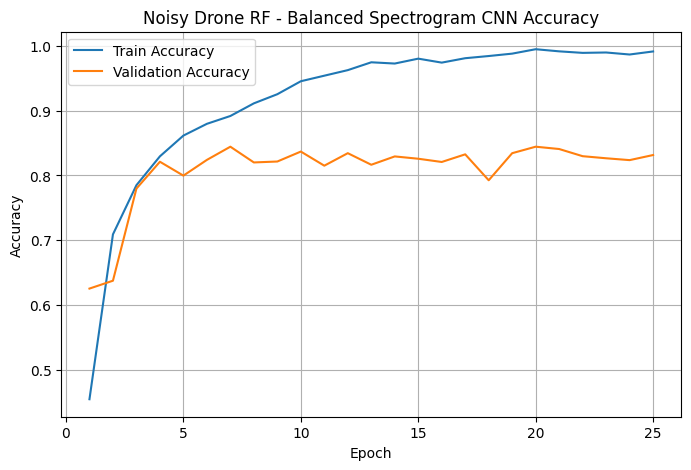

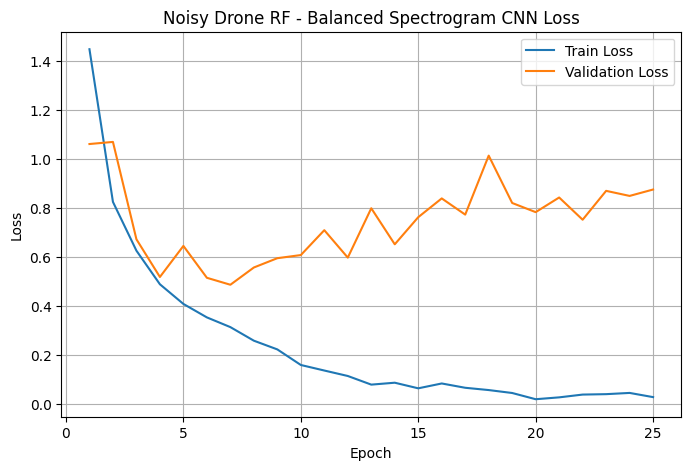

In [10]:
import matplotlib.pyplot as plt

history_path = os.path.join(SAVE_DIR, "history.csv")
history_df = pd.read_csv(history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["valid_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["valid_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Noisy Drone RF - Balanced Spectrogram CNN Loss")
plt.legend()
plt.grid(True)
plt.show()


## 11. Classification report and confusion matrix

Use macro F1 because this dataset is naturally imbalanced, even though this first subset is balanced.


Loaded best model: /kaggle/working/noisy_drone_resnet18_spec_balanced/best.pt
              precision    recall  f1-score   support

         DJI       0.92      0.86      0.89       400
   FutabaT14       0.92      0.82      0.87       400
    FutabaT7       0.83      0.81      0.82       400
    Graupner       0.89      0.91      0.90       400
       Noise       0.62      0.90      0.73       400
     Taranis       0.98      0.90      0.93       400
     Turnigy       0.87      0.72      0.79       400

    accuracy                           0.84      2800
   macro avg       0.86      0.84      0.85      2800
weighted avg       0.86      0.84      0.85      2800



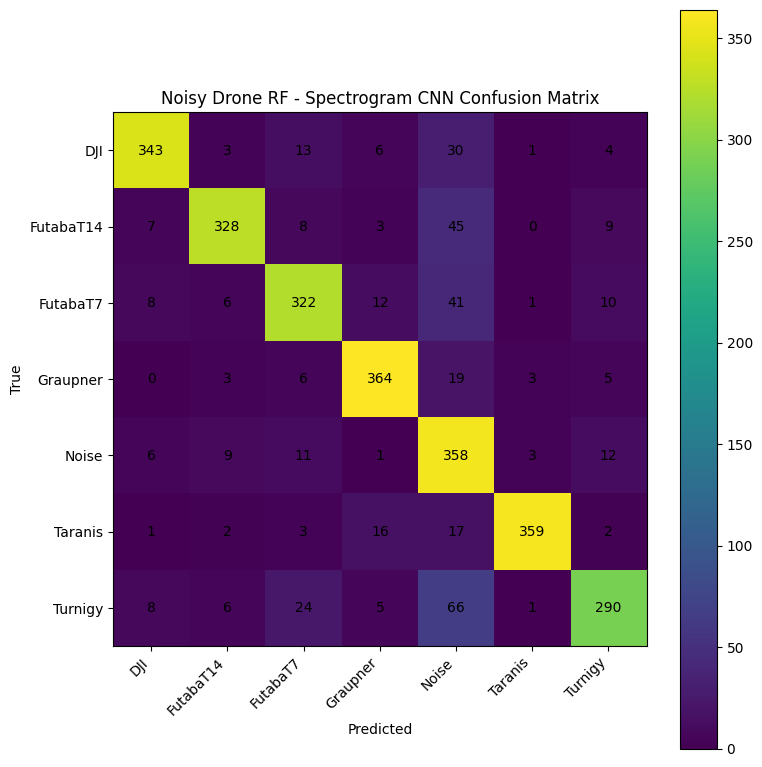

Saved confusion matrix to: /kaggle/working/noisy_drone_resnet18_spec_balanced/confusion_matrix.png


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model before evaluation
best_path = os.path.join(SAVE_DIR, "best.pt")
if os.path.exists(best_path):
    model.load_state_dict(torch.load(best_path, map_location=device))
    print("Loaded best model:", best_path)

model.eval()
all_preds = []
all_labels = []
all_snrs = []

with torch.no_grad():
    for x, labels, snrs in valid_loader:
        x = x.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(x)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_snrs.extend(snrs.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Noisy Drone RF - Spectrogram CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()
print("Saved confusion matrix to:", cm_path)


## 12. Accuracy by SNR

This is one of the most important analyses for this dataset.

Low SNR values like `-20 dB` should be harder. High SNR values like `20 dB` to `30 dB` should be easier.


,SNR,accuracy
0,-20,0.140187
1,-18,0.351064
2,-16,0.495146
3,-14,0.587302
4,-12,0.715686
5,-10,0.755814
6,-8,0.826923
7,-6,0.862745
8,-4,0.867347
9,-2,0.918033


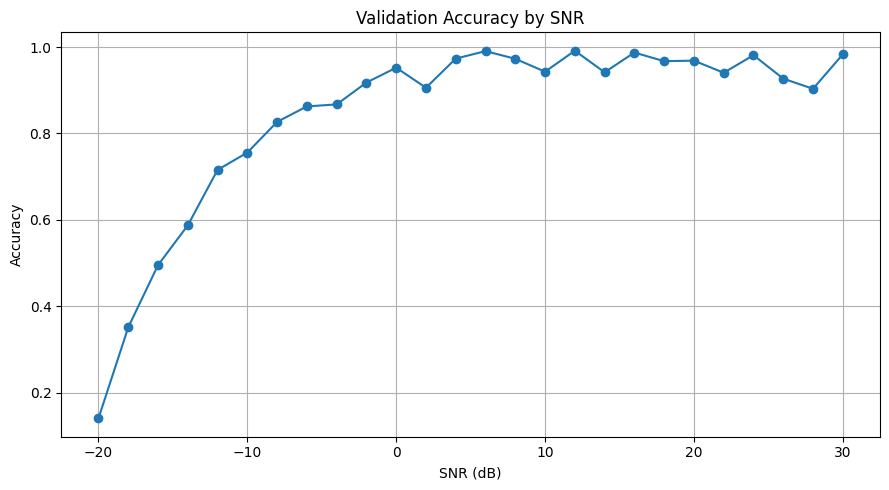

Saved SNR accuracy plot to: /kaggle/working/noisy_drone_resnet18_spec_balanced/accuracy_by_snr.png


In [12]:
results_df = pd.DataFrame({
    "label": all_labels,
    "pred": all_preds,
    "snr": all_snrs,
})
results_df["correct"] = results_df["label"] == results_df["pred"]

snr_acc = results_df.groupby("snr")["correct"].mean().reset_index()
snr_acc.columns = ["SNR", "accuracy"]
display(snr_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_acc["SNR"], snr_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()
snr_path = os.path.join(SAVE_DIR, "accuracy_by_snr.png")
plt.savefig(snr_path, dpi=200)
plt.show()
print("Saved SNR accuracy plot to:", snr_path)


## 13. Confusion matrices by SNR group

The overall confusion matrix hides where the model fails. This section splits the validation set into low, medium, and high SNR groups, then creates a separate confusion matrix for each group.

Suggested groups:

```text
Low SNR:    -20 to -10 dB
Medium SNR: -8 to 4 dB
High SNR:    6 to 30 dB
```

This helps show whether errors such as `Turnigy → Noise` mainly happen when the RF signal is weak.


low_snr_-20_to_-10: SNR -20 to -10 dB
Samples: 618
Accuracy: 0.5032

Classification report:
              precision    recall  f1-score   support

         DJI       0.71      0.42      0.53        81
   FutabaT14       0.69      0.27      0.39        88
    FutabaT7       0.49      0.35      0.41        88
    Graupner       0.69      0.63      0.66        87
       Noise       0.29      0.91      0.43        87
     Taranis       0.93      0.60      0.73        86
     Turnigy       0.61      0.36      0.45       101

    accuracy                           0.50       618
   macro avg       0.63      0.51      0.51       618
weighted avg       0.63      0.50      0.51       618



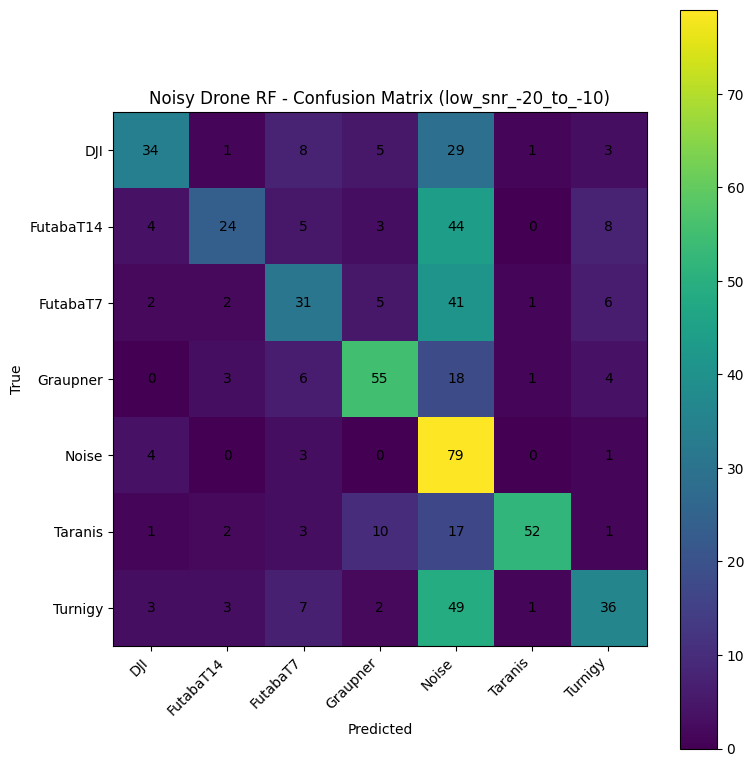

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced/confusion_matrix_low_snr_-20_to_-10.png
medium_snr_-8_to_4: SNR -8 to 4 dB
Samples: 761
Accuracy: 0.9028

Classification report:
              precision    recall  f1-score   support

         DJI       0.88      0.94      0.91       112
   FutabaT14       0.92      0.94      0.93       112
    FutabaT7       0.87      0.84      0.86       106
    Graupner       0.93      0.97      0.95       119
       Noise       0.86      0.90      0.88       104
     Taranis       0.97      0.96      0.97       111
     Turnigy       0.87      0.73      0.79        97

    accuracy                           0.90       761
   macro avg       0.90      0.90      0.90       761
weighted avg       0.90      0.90      0.90       761



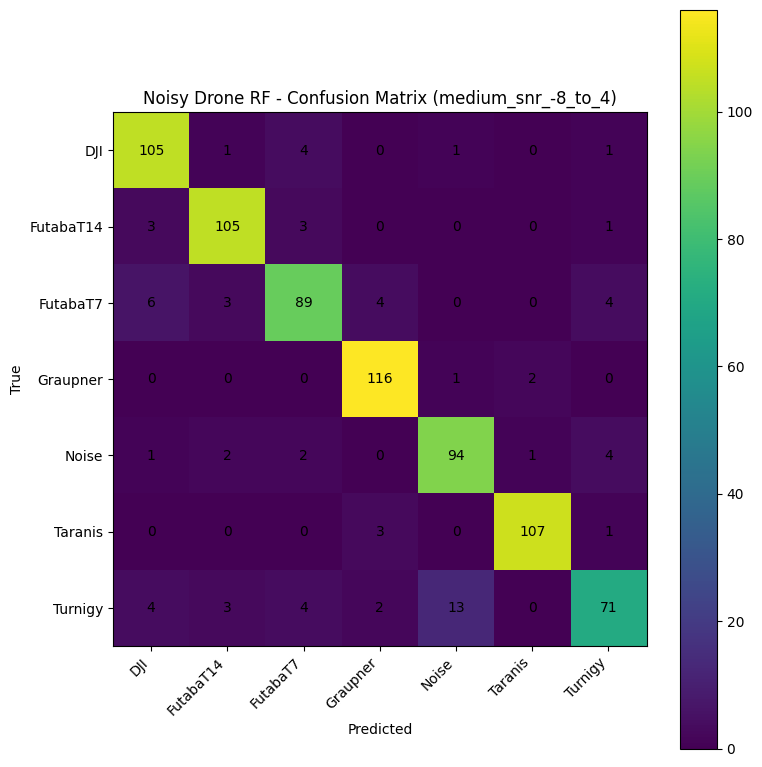

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced/confusion_matrix_medium_snr_-8_to_4.png
high_snr_6_to_30: SNR 6 to 30 dB
Samples: 1421
Accuracy: 0.9613

Classification report:
              precision    recall  f1-score   support

         DJI       0.99      0.99      0.99       207
   FutabaT14       0.96      0.99      0.98       200
    FutabaT7       0.91      0.98      0.94       206
    Graupner       0.96      0.99      0.97       194
       Noise       0.97      0.89      0.93       209
     Taranis       0.99      0.99      0.99       203
     Turnigy       0.96      0.91      0.93       202

    accuracy                           0.96      1421
   macro avg       0.96      0.96      0.96      1421
weighted avg       0.96      0.96      0.96      1421



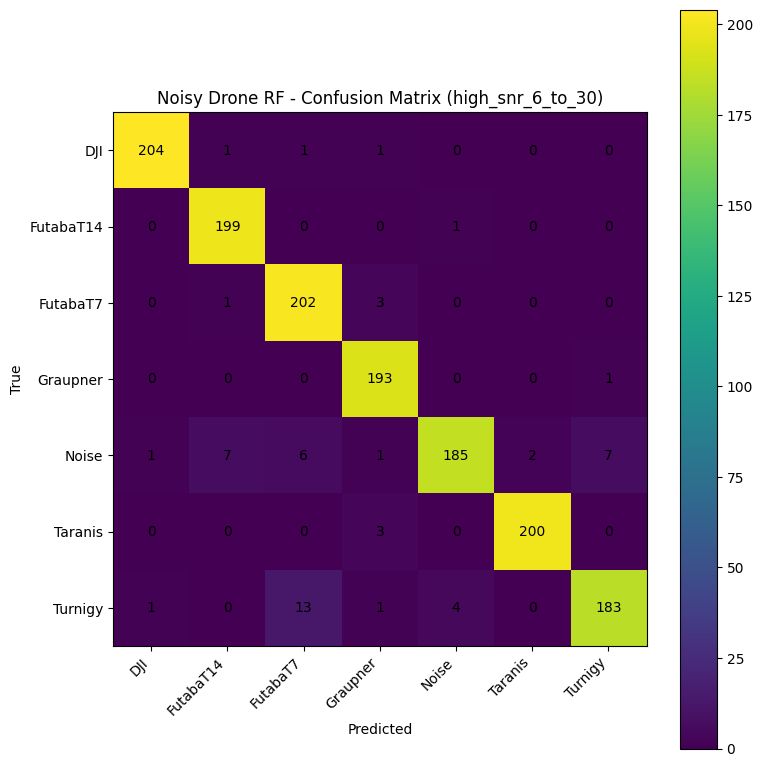

Saved: /kaggle/working/noisy_drone_resnet18_spec_balanced/confusion_matrix_high_snr_6_to_30.png


,group,snr_min,snr_max,samples,accuracy
0,low_snr_-20_to_-10,-20,-10,618,0.503236
1,medium_snr_-8_to_4,-8,4,761,0.902760
2,high_snr_6_to_30,6,30,1421,0.961295


Saved SNR group summary to: /kaggle/working/noisy_drone_resnet18_spec_balanced/snr_group_summary.csv


In [13]:

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# This cell expects these variables from the evaluation cell:
# all_labels, all_preds, all_snrs, class_names, SAVE_DIR

results_df = pd.DataFrame({
    "label": np.array(all_labels),
    "pred": np.array(all_preds),
    "snr": np.array(all_snrs),
})

results_df["correct"] = results_df["label"] == results_df["pred"]

snr_groups = {
    "low_snr_-20_to_-10": (-20, -10),
    "medium_snr_-8_to_4": (-8, 4),
    "high_snr_6_to_30": (6, 30),
}

def plot_confusion_matrix_for_subset(df_subset, title, save_path):
    labels = list(range(len(class_names)))
    cm = confusion_matrix(df_subset["label"], df_subset["pred"], labels=labels)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(len(class_names)), class_names)
    plt.colorbar()

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

    return cm

snr_summary_rows = []

for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = results_df[(results_df["snr"] >= snr_min) & (results_df["snr"] <= snr_max)].copy()

    if len(subset) == 0:
        print(f"No validation samples found for {group_name}")
        continue

    acc = subset["correct"].mean()
    print("=" * 80)
    print(f"{group_name}: SNR {snr_min} to {snr_max} dB")
    print(f"Samples: {len(subset)}")
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification report:")
    print(classification_report(
        subset["label"],
        subset["pred"],
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0,
    ))

    save_path = os.path.join(SAVE_DIR, f"confusion_matrix_{group_name}.png")
    cm_group = plot_confusion_matrix_for_subset(
        subset,
        f"Noisy Drone RF - Confusion Matrix ({group_name})",
        save_path
    )
    print("Saved:", save_path)

    snr_summary_rows.append({
        "group": group_name,
        "snr_min": snr_min,
        "snr_max": snr_max,
        "samples": len(subset),
        "accuracy": acc,
    })

snr_group_summary = pd.DataFrame(snr_summary_rows)
display(snr_group_summary)

summary_path = os.path.join(SAVE_DIR, "snr_group_summary.csv")
snr_group_summary.to_csv(summary_path, index=False)
print("Saved SNR group summary to:", summary_path)


## 14. Two-stage model: Noise detector → Drone classifier

This section uses the existing `Noise` class in the Kaggle noisy-drone dataset.

The pipeline is:

```text
Stage 1: Noise vs Signal
    Noise          → 0
    All drone data → 1

Stage 2: Drone-only classifier
    Train only on drone classes
    Remove Noise from Stage 2

Full pipeline:
    If Stage 1 predicts Noise → final prediction = Noise
    If Stage 1 predicts Signal → send sample to Stage 2
```

This is more realistic than a single classifier because real RF monitoring may receive both drone transmissions and background/noise-only samples.

In [14]:
# Two-stage experiment setup
from pathlib import Path
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

TWO_STAGE_SAVE_DIR = Path('/kaggle/working/noisy_drone_two_stage_spec')
TWO_STAGE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

noise_class_name = 'Noise'
noise_class_id = class_names.index(noise_class_name)

drone_class_ids = [i for i, name in enumerate(class_names) if name != noise_class_name]
drone_class_names = [class_names[i] for i in drone_class_ids]

# Mapping from original dataset class id to compact Stage 2 class id.
orig_to_drone = {orig_id: new_id for new_id, orig_id in enumerate(drone_class_ids)}
drone_to_orig = {new_id: orig_id for orig_id, new_id in orig_to_drone.items()}

print('Noise class:', noise_class_name, 'id =', noise_class_id)
print('Drone classes:', drone_class_names)
print('Save directory:', TWO_STAGE_SAVE_DIR)

Noise class: Noise id = 4
Drone classes: ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Taranis', 'Turnigy']
Save directory: /kaggle/working/noisy_drone_two_stage_spec


### 14.1 Build Stage 1 and Stage 2 datasets

Stage 1 keeps all samples but collapses labels into binary labels.

Stage 2 removes the `Noise` class and remaps the remaining drone labels to `0..5`.

In [15]:
class Stage1SignalNoiseDataset(Dataset):
    """Binary dataset: 0 = Noise, 1 = Signal."""
    def __init__(self, data, indices, noise_class_id):
        self.x_spec = data['x_spec']
        self.y = data['y']
        self.snr = data['snr']
        self.indices = list(indices)
        self.noise_class_id = int(noise_class_id)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]
        original_label = int(self.y[real_idx])
        binary_label = 0 if original_label == self.noise_class_id else 1
        snr = self.snr[real_idx]
        return x, torch.tensor(binary_label, dtype=torch.long), torch.tensor(original_label, dtype=torch.long), snr


class Stage2DroneOnlyDataset(Dataset):
    """Drone-only multiclass dataset. Noise samples are removed."""
    def __init__(self, data, indices, noise_class_id, orig_to_drone):
        self.x_spec = data['x_spec']
        self.y = data['y']
        self.snr = data['snr']
        self.noise_class_id = int(noise_class_id)
        self.orig_to_drone = dict(orig_to_drone)

        self.indices = []
        for real_idx in indices:
            original_label = int(self.y[int(real_idx)])
            if original_label != self.noise_class_id:
                self.indices.append(int(real_idx))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = int(self.indices[idx])
        x = self.x_spec[real_idx]
        original_label = int(self.y[real_idx])
        drone_label = self.orig_to_drone[original_label]
        snr = self.snr[real_idx]
        return x, torch.tensor(drone_label, dtype=torch.long), torch.tensor(original_label, dtype=torch.long), snr


stage1_train_dataset = Stage1SignalNoiseDataset(data, train_indices, noise_class_id)
stage1_valid_dataset = Stage1SignalNoiseDataset(data, valid_indices, noise_class_id)

stage2_train_dataset = Stage2DroneOnlyDataset(data, train_indices, noise_class_id, orig_to_drone)
stage2_valid_dataset = Stage2DroneOnlyDataset(data, valid_indices, noise_class_id, orig_to_drone)

stage1_train_loader = DataLoader(stage1_train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
stage1_valid_loader = DataLoader(stage1_valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

stage2_train_loader = DataLoader(stage2_train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
stage2_valid_loader = DataLoader(stage2_valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

print('Stage 1 train samples:', len(stage1_train_dataset))
print('Stage 1 valid samples:', len(stage1_valid_dataset))
print('Stage 2 train samples:', len(stage2_train_dataset))
print('Stage 2 valid samples:', len(stage2_valid_dataset))

# Check binary class balance for Stage 1.
stage1_train_binary = [0 if int(y[int(i)]) == noise_class_id else 1 for i in train_indices]
stage1_valid_binary = [0 if int(y[int(i)]) == noise_class_id else 1 for i in valid_indices]
print('Stage 1 train binary counts [Noise, Signal]:', np.bincount(stage1_train_binary, minlength=2))
print('Stage 1 valid binary counts [Noise, Signal]:', np.bincount(stage1_valid_binary, minlength=2))

Stage 1 train samples: 11900
Stage 1 valid samples: 2800
Stage 2 train samples: 10200
Stage 2 valid samples: 2400
Stage 1 train binary counts [Noise, Signal]: [ 1700 10200]
Stage 1 valid binary counts [Noise, Signal]: [ 400 2400]


### 14.2 Reusable training and evaluation helpers

These helper functions train a ResNet18 model and save the best checkpoint based on validation accuracy.

In [16]:
def train_resnet_model(model, train_loader, valid_loader, save_dir, model_name, epochs):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_acc = 0.0
    history = []

    for epoch in range(epochs):
        print('=' * 60)
        print(f'{model_name} - Epoch {epoch + 1}/{epochs}')

        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch in tqdm(train_loader, desc=f'{model_name} training'):
            x = batch[0].to(device, non_blocking=True)
            labels = batch[1].to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total

        model.eval()
        valid_loss = 0.0
        valid_correct = 0
        valid_total = 0

        with torch.no_grad():
            for batch in tqdm(valid_loader, desc=f'{model_name} validation'):
                x = batch[0].to(device, non_blocking=True)
                labels = batch[1].to(device, non_blocking=True)

                outputs = model(x)
                loss = criterion(outputs, labels)

                valid_loss += loss.item() * x.size(0)
                preds = outputs.argmax(dim=1)
                valid_correct += (preds == labels).sum().item()
                valid_total += labels.size(0)

        valid_loss /= valid_total
        valid_acc = valid_correct / valid_total

        row = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'valid_loss': valid_loss,
            'valid_acc': valid_acc,
        }
        history.append(row)
        print(row)

        if valid_acc > best_acc:
            best_acc = valid_acc
            torch.save(model.state_dict(), save_dir / f'{model_name}_best.pt')
            print('Saved new best checkpoint')

    torch.save(model.state_dict(), save_dir / f'{model_name}_last.pt')
    history_df = pd.DataFrame(history)
    history_df.to_csv(save_dir / f'{model_name}_history.csv', index=False)
    return history_df


def collect_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_original_labels, all_snrs = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device, non_blocking=True)
            labels = batch[1].to(device, non_blocking=True)
            original_labels = batch[2]
            snrs = batch[3]

            outputs = model(x)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_original_labels.extend(original_labels.cpu().numpy())
            all_snrs.extend(snrs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_original_labels), np.array(all_snrs)

### 14.3 Train Stage 1: Noise vs Signal detector

This model only decides whether the input is background/noise or a drone signal.

In [17]:
stage1_detector = ResNet18RFSpec(num_classes=2).to(device)
stage1_epochs = 2 if QUICK_TEST else 10

stage1_history = train_resnet_model(
    model=stage1_detector,
    train_loader=stage1_train_loader,
    valid_loader=stage1_valid_loader,
    save_dir=TWO_STAGE_SAVE_DIR,
    model_name='stage1_signal_noise_detector',
    epochs=stage1_epochs,
)

display(stage1_history)

stage1_signal_noise_detector - Epoch 1/10


stage1_signal_noise_detector validation: 100%|██████████| 44/44 [00:00<00:00, 48.58it/s]


{'epoch': 1, 'train_loss': 0.31081208535603116, 'train_acc': 0.8742016806722689, 'valid_loss': 0.29148563061441696, 'valid_acc': 0.8817857142857143}
Saved new best checkpoint
stage1_signal_noise_detector - Epoch 2/10


stage1_signal_noise_detector validation: 100%|██████████| 44/44 [00:00<00:00, 48.10it/s]


{'epoch': 2, 'train_loss': 0.21900760945652714, 'train_acc': 0.9010924369747899, 'valid_loss': 0.2908174501146589, 'valid_acc': 0.8760714285714286}
stage1_signal_noise_detector - Epoch 3/10


...

stage1_signal_noise_detector validation: 100%|██████████| 44/44 [00:00<00:00, 48.52it/s]


{'epoch': 9, 'train_loss': 0.049222969144833185, 'train_acc': 0.9821848739495799, 'valid_loss': 0.2854531046322414, 'valid_acc': 0.9160714285714285}
stage1_signal_noise_detector - Epoch 10/10


stage1_signal_noise_detector validation: 100%|██████████| 44/44 [00:00<00:00, 48.75it/s]


{'epoch': 10, 'train_loss': 0.037729159773272625, 'train_acc': 0.986890756302521, 'valid_loss': 0.5396989965438843, 'valid_acc': 0.8678571428571429}


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,0.310812,0.874202,0.291486,0.881786
1,2,0.219008,0.901092,0.290817,0.876071
2,3,0.174362,0.926807,0.358114,0.857143
3,4,0.146610,0.937983,0.252860,0.907857
4,5,0.123532,0.948655,0.248739,0.900714
5,6,0.089502,0.964034,0.492162,0.862857
6,7,0.079663,0.969832,0.502079,0.877143
7,8,0.060402,0.976134,0.296220,0.917500
8,9,0.049223,0.982185,0.285453,0.916071
9,10,0.037729,0.986891,0.539699,0.867857


              precision    recall  f1-score   support

       Noise       0.82      0.55      0.65       400
      Signal       0.93      0.98      0.95      2400

    accuracy                           0.92      2800
   macro avg       0.87      0.76      0.80      2800
weighted avg       0.91      0.92      0.91      2800



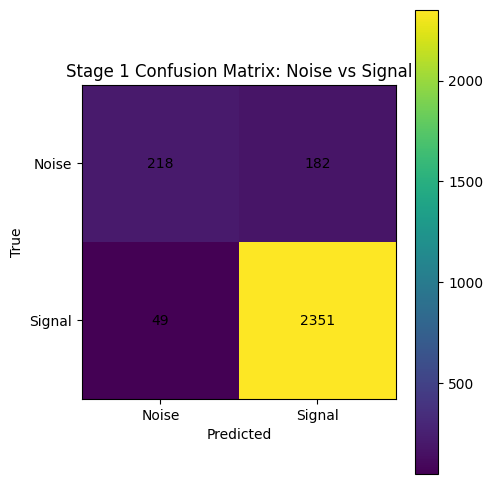

Saved: /kaggle/working/noisy_drone_two_stage_spec/stage1_noise_signal_confusion_matrix.png


,noise_rejection_accuracy,signal_detection_accuracy,missed_detection_rate_signal_as_noise,false_alarm_rate_noise_as_signal
0,0.545,0.979583,0.020417,0.455


In [18]:
# Evaluate Stage 1 alone.
stage1_best_path = TWO_STAGE_SAVE_DIR / 'stage1_signal_noise_detector_best.pt'
stage1_detector.load_state_dict(torch.load(stage1_best_path, map_location=device))

stage1_preds, stage1_labels, stage1_original_labels, stage1_snrs = collect_predictions(stage1_detector, stage1_valid_loader)

stage1_names = ['Noise', 'Signal']
print(classification_report(stage1_labels, stage1_preds, target_names=stage1_names))

stage1_cm = confusion_matrix(stage1_labels, stage1_preds, labels=[0, 1])
plt.figure(figsize=(5, 5))
plt.imshow(stage1_cm)
plt.title('Stage 1 Confusion Matrix: Noise vs Signal')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(2), stage1_names)
plt.yticks(np.arange(2), stage1_names)
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, int(stage1_cm[i, j]), ha='center', va='center')
plt.tight_layout()
stage1_cm_path = TWO_STAGE_SAVE_DIR / 'stage1_noise_signal_confusion_matrix.png'
plt.savefig(stage1_cm_path, dpi=200)
plt.show()
print('Saved:', stage1_cm_path)

# Useful detector metrics.
true_noise = stage1_labels == 0
true_signal = stage1_labels == 1
noise_rejection_acc = (stage1_preds[true_noise] == 0).mean() if true_noise.any() else np.nan
signal_detection_acc = (stage1_preds[true_signal] == 1).mean() if true_signal.any() else np.nan
missed_detection_rate = (stage1_preds[true_signal] == 0).mean() if true_signal.any() else np.nan
false_alarm_rate = (stage1_preds[true_noise] == 1).mean() if true_noise.any() else np.nan

stage1_metric_df = pd.DataFrame([{
    'noise_rejection_accuracy': noise_rejection_acc,
    'signal_detection_accuracy': signal_detection_acc,
    'missed_detection_rate_signal_as_noise': missed_detection_rate,
    'false_alarm_rate_noise_as_signal': false_alarm_rate,
}])
display(stage1_metric_df)
stage1_metric_df.to_csv(TWO_STAGE_SAVE_DIR / 'stage1_detector_metrics.csv', index=False)

### 14.4 Train Stage 2: drone-only classifier

This model does **not** see noise during training. It only classifies drone/controller classes after Stage 1 says the input is a signal.

In [19]:
stage2_classifier = ResNet18RFSpec(num_classes=len(drone_class_names)).to(device)
stage2_epochs = 2 if QUICK_TEST else 20

stage2_history = train_resnet_model(
    model=stage2_classifier,
    train_loader=stage2_train_loader,
    valid_loader=stage2_valid_loader,
    save_dir=TWO_STAGE_SAVE_DIR,
    model_name='stage2_drone_classifier',
    epochs=stage2_epochs,
)

display(stage2_history)

stage2_drone_classifier - Epoch 1/20


stage2_drone_classifier validation: 100%|██████████| 38/38 [00:00<00:00, 48.37it/s]


{'epoch': 1, 'train_loss': 1.043468861252654, 'train_acc': 0.5888235294117647, 'valid_loss': 0.6807865444819132, 'valid_acc': 0.7445833333333334}
Saved new best checkpoint
stage2_drone_classifier - Epoch 2/20


stage2_drone_classifier validation: 100%|██████████| 38/38 [00:00<00:00, 48.62it/s]


{'epoch': 2, 'train_loss': 0.6177099610777462, 'train_acc': 0.7663725490196078, 'valid_loss': 0.5661196303367615, 'valid_acc': 0.775}
Saved new best checkpoint
stage2_drone_classifier - Epoch 3/20


...

stage2_drone_classifier validation: 100%|██████████| 38/38 [00:00<00:00, 49.02it/s]


{'epoch': 19, 'train_loss': 0.04220866583725985, 'train_acc': 0.9862745098039216, 'valid_loss': 0.742403682867686, 'valid_acc': 0.8383333333333334}
stage2_drone_classifier - Epoch 20/20


stage2_drone_classifier validation: 100%|██████████| 38/38 [00:00<00:00, 48.39it/s]


{'epoch': 20, 'train_loss': 0.044809133668302324, 'train_acc': 0.9855882352941177, 'valid_loss': 0.6347395650545756, 'valid_acc': 0.87375}
Saved new best checkpoint


,epoch,train_loss,train_acc,valid_loss,valid_acc
0,1,1.043469,0.588824,0.680787,0.744583
1,2,0.617710,0.766373,0.566120,0.775000
2,3,0.462646,0.827353,0.500660,0.810417
3,4,0.353276,0.872549,0.954177,0.752500
4,5,0.271844,0.904020,0.461557,0.844167
5,6,0.184677,0.936667,0.730087,0.792083
6,7,0.178673,0.941275,0.525706,0.835417
7,8,0.096980,0.968235,0.715539,0.831250
8,9,0.056523,0.981471,0.612555,0.849167
9,10,0.067012,0.978824,0.635792,0.845833


              precision    recall  f1-score   support

         DJI       0.91      0.86      0.89       400
   FutabaT14       0.79      0.88      0.83       400
    FutabaT7       0.83      0.85      0.84       400
    Graupner       0.95      0.90      0.93       400
     Taranis       0.98      0.91      0.94       400
     Turnigy       0.81      0.83      0.82       400

    accuracy                           0.87      2400
   macro avg       0.88      0.87      0.87      2400
weighted avg       0.88      0.87      0.87      2400



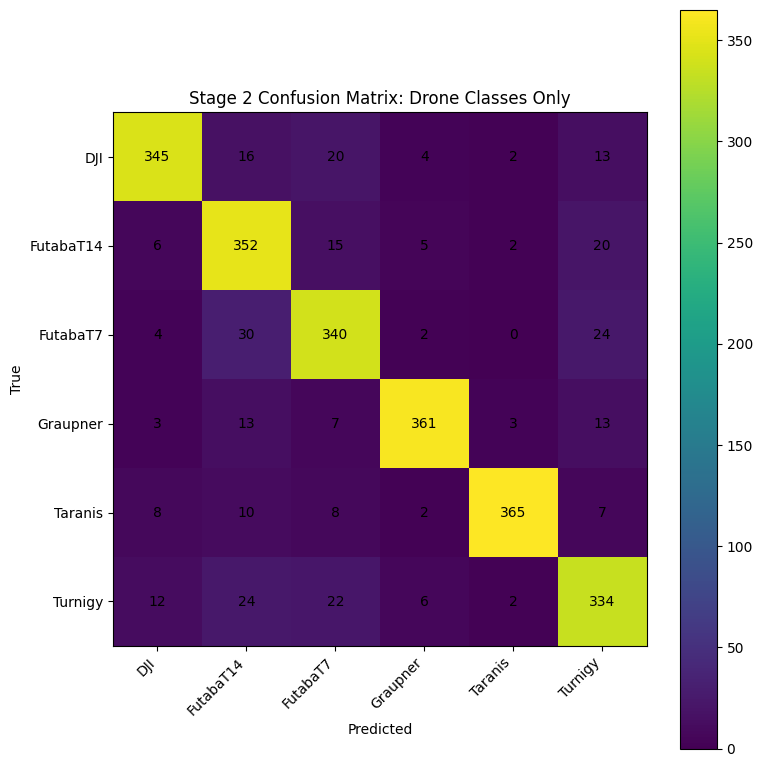

Saved: /kaggle/working/noisy_drone_two_stage_spec/stage2_drone_confusion_matrix.png


In [20]:
# Evaluate Stage 2 alone on true drone samples only.
stage2_best_path = TWO_STAGE_SAVE_DIR / 'stage2_drone_classifier_best.pt'
stage2_classifier.load_state_dict(torch.load(stage2_best_path, map_location=device))

stage2_preds, stage2_labels, stage2_original_labels, stage2_snrs = collect_predictions(stage2_classifier, stage2_valid_loader)

print(classification_report(stage2_labels, stage2_preds, target_names=drone_class_names))

stage2_cm = confusion_matrix(stage2_labels, stage2_preds, labels=list(range(len(drone_class_names))))
plt.figure(figsize=(8, 8))
plt.imshow(stage2_cm)
plt.title('Stage 2 Confusion Matrix: Drone Classes Only')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(len(drone_class_names)), drone_class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(drone_class_names)), drone_class_names)
plt.colorbar()
for i in range(len(drone_class_names)):
    for j in range(len(drone_class_names)):
        plt.text(j, i, int(stage2_cm[i, j]), ha='center', va='center')
plt.tight_layout()
stage2_cm_path = TWO_STAGE_SAVE_DIR / 'stage2_drone_confusion_matrix.png'
plt.savefig(stage2_cm_path, dpi=200)
plt.show()
print('Saved:', stage2_cm_path)

### 14.5 Evaluate the full two-stage pipeline

The full pipeline is stricter than Stage 2 alone:

- A true `Noise` sample is correct only if the final output is `Noise`.
- A true drone sample is correct only if Stage 1 says `Signal` **and** Stage 2 predicts the correct drone class.

The code below also tests different Stage 1 signal thresholds. A lower threshold usually protects low-SNR drone signals from being rejected as noise.

In [21]:
def two_stage_pipeline_predict(detector, classifier, loader, signal_threshold=0.5):
    detector.eval()
    classifier.eval()

    final_preds_original = []
    true_original = []
    snrs = []
    signal_probs = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Pipeline threshold={signal_threshold}'):
            x = batch[0].to(device, non_blocking=True)
            original_labels = batch[2].cpu().numpy()
            batch_snrs = batch[3].cpu().numpy()

            det_logits = detector(x)
            det_probs = F.softmax(det_logits, dim=1)
            batch_signal_probs = det_probs[:, 1]

            # Start all final predictions as Noise.
            batch_final = np.full(shape=(x.size(0),), fill_value=noise_class_id, dtype=np.int64)

            signal_mask = batch_signal_probs >= signal_threshold
            if signal_mask.any():
                signal_x = x[signal_mask]
                cls_logits = classifier(signal_x)
                cls_preds_drone = cls_logits.argmax(dim=1).cpu().numpy()

                # Convert compact Stage 2 drone ids back to original dataset ids.
                cls_preds_original = np.array([drone_to_orig[int(p)] for p in cls_preds_drone], dtype=np.int64)
                batch_final[signal_mask.cpu().numpy()] = cls_preds_original

            final_preds_original.extend(batch_final.tolist())
            true_original.extend(original_labels.tolist())
            snrs.extend(batch_snrs.tolist())
            signal_probs.extend(batch_signal_probs.cpu().numpy().tolist())

    return (
        np.array(final_preds_original),
        np.array(true_original),
        np.array(snrs),
        np.array(signal_probs),
    )

threshold_rows = []
threshold_results = {}

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    final_preds, true_orig, pipe_snrs, signal_probs = two_stage_pipeline_predict(
        stage1_detector,
        stage2_classifier,
        stage1_valid_loader,
        signal_threshold=threshold,
    )

    correct = final_preds == true_orig
    is_noise = true_orig == noise_class_id
    is_signal = true_orig != noise_class_id

    row = {
        'signal_threshold': threshold,
        'full_pipeline_accuracy': correct.mean(),
        'noise_accuracy': (final_preds[is_noise] == noise_class_id).mean() if is_noise.any() else np.nan,
        'drone_end_to_end_accuracy': correct[is_signal].mean() if is_signal.any() else np.nan,
        'missed_detection_rate_drone_as_noise': (final_preds[is_signal] == noise_class_id).mean() if is_signal.any() else np.nan,
        'false_alarm_rate_noise_as_drone': (final_preds[is_noise] != noise_class_id).mean() if is_noise.any() else np.nan,
    }
    threshold_rows.append(row)
    threshold_results[threshold] = (final_preds, true_orig, pipe_snrs, signal_probs)

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
threshold_df.to_csv(TWO_STAGE_SAVE_DIR / 'pipeline_threshold_results.csv', index=False)

# Pick a balanced default. You can change this after looking at the threshold table.
best_threshold = 0.4
final_preds, true_orig, pipe_snrs, signal_probs = threshold_results[best_threshold]

print('Using threshold:', best_threshold)
print(classification_report(true_orig, final_preds, target_names=class_names))

Pipeline threshold=0.7: 100%|██████████| 44/44 [00:01<00:00, 26.10it/s]


,signal_threshold,full_pipeline_accuracy,noise_accuracy,drone_end_to_end_accuracy,missed_detection_rate_drone_as_noise,false_alarm_rate_noise_as_drone
0,0.3,0.818571,0.5075,0.870417,0.012083,0.4925
1,0.4,0.820000,0.5300,0.868333,0.016250,0.4700
2,0.5,0.820714,0.5450,0.866667,0.020417,0.4550
3,0.6,0.823214,0.5700,0.865417,0.022083,0.4300
4,0.7,0.824643,0.6000,0.862083,0.030000,0.4000


Using threshold: 0.4
              precision    recall  f1-score   support

         DJI       0.89      0.86      0.87       400
   FutabaT14       0.70      0.87      0.77       400
    FutabaT7       0.77      0.84      0.81       400
    Graupner       0.92      0.90      0.91       400
       Noise       0.84      0.53      0.65       400
     Taranis       0.96      0.91      0.93       400
     Turnigy       0.73      0.83      0.78       400

    accuracy                           0.82      2800
   macro avg       0.83      0.82      0.82      2800
weighted avg       0.83      0.82      0.82      2800



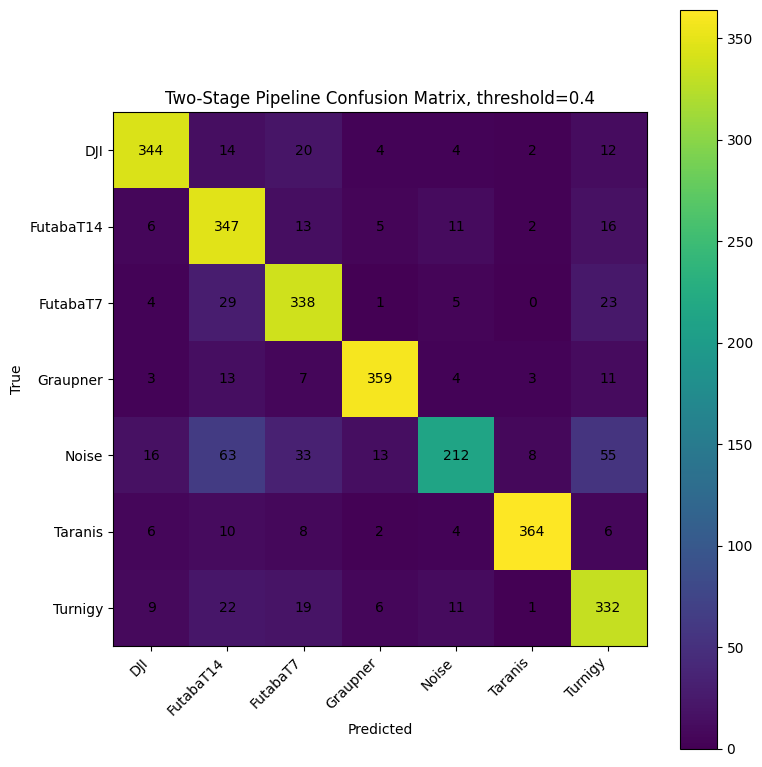

Saved: /kaggle/working/noisy_drone_two_stage_spec/two_stage_pipeline_confusion_matrix_threshold_0.4.png


,true_label_id,true_label_name,pred_label_id,pred_label_name,snr,signal_prob,correct
0,3,Graupner,3,Graupner,6,0.999911,True
1,1,FutabaT14,0,DJI,26,0.999993,False
2,0,DJI,0,DJI,-14,0.907759,True
3,2,FutabaT7,2,FutabaT7,26,0.996490,True
4,2,FutabaT7,2,FutabaT7,30,0.999283,True


In [22]:
# Full pipeline confusion matrix using the selected threshold.
pipe_cm = confusion_matrix(true_orig, final_preds, labels=list(range(len(class_names))))

plt.figure(figsize=(8, 8))
plt.imshow(pipe_cm)
plt.title(f'Two-Stage Pipeline Confusion Matrix, threshold={best_threshold}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, int(pipe_cm[i, j]), ha='center', va='center')
plt.tight_layout()
pipe_cm_path = TWO_STAGE_SAVE_DIR / f'two_stage_pipeline_confusion_matrix_threshold_{best_threshold}.png'
plt.savefig(pipe_cm_path, dpi=200)
plt.show()
print('Saved:', pipe_cm_path)

pipeline_results_df = pd.DataFrame({
    'true_label_id': true_orig,
    'true_label_name': [class_names[int(i)] for i in true_orig],
    'pred_label_id': final_preds,
    'pred_label_name': [class_names[int(i)] for i in final_preds],
    'snr': pipe_snrs,
    'signal_prob': signal_probs,
})
pipeline_results_df['correct'] = pipeline_results_df['true_label_id'] == pipeline_results_df['pred_label_id']
pipeline_results_df.to_csv(TWO_STAGE_SAVE_DIR / 'two_stage_pipeline_predictions.csv', index=False)
display(pipeline_results_df.head())

### 14.6 Two-stage accuracy by SNR group

This shows whether Stage 1 is rejecting low-SNR drone signals as `Noise`.

,snr_group,samples,full_pipeline_accuracy,noise_accuracy,drone_end_to_end_accuracy,missed_detection_rate_drone_as_noise
0,low_snr_-20_to_-10,618,0.504854,0.402299,0.521657,0.056497
1,medium_snr_-8_to_4,761,0.894875,0.663462,0.931507,0.009132
2,high_snr_6_to_30,1421,0.916960,0.516746,0.985974,0.002475


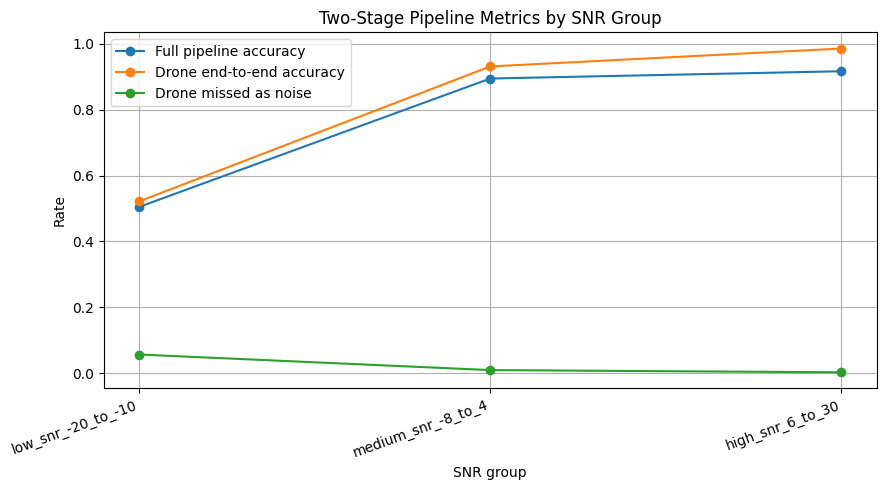

Saved: /kaggle/working/noisy_drone_two_stage_spec/two_stage_pipeline_snr_group_metrics.png


In [23]:
snr_groups = {
    'low_snr_-20_to_-10': (-20, -10),
    'medium_snr_-8_to_4': (-8, 4),
    'high_snr_6_to_30': (6, 30),
}

snr_group_rows = []
for group_name, (snr_min, snr_max) in snr_groups.items():
    subset = pipeline_results_df[(pipeline_results_df['snr'] >= snr_min) & (pipeline_results_df['snr'] <= snr_max)].copy()
    if len(subset) == 0:
        continue

    is_noise = subset['true_label_id'] == noise_class_id
    is_drone = subset['true_label_id'] != noise_class_id

    row = {
        'snr_group': group_name,
        'samples': len(subset),
        'full_pipeline_accuracy': subset['correct'].mean(),
        'noise_accuracy': (subset.loc[is_noise, 'pred_label_id'] == noise_class_id).mean() if is_noise.any() else np.nan,
        'drone_end_to_end_accuracy': subset.loc[is_drone, 'correct'].mean() if is_drone.any() else np.nan,
        'missed_detection_rate_drone_as_noise': (subset.loc[is_drone, 'pred_label_id'] == noise_class_id).mean() if is_drone.any() else np.nan,
    }
    snr_group_rows.append(row)

snr_group_df = pd.DataFrame(snr_group_rows)
display(snr_group_df)
snr_group_df.to_csv(TWO_STAGE_SAVE_DIR / 'two_stage_pipeline_snr_group_metrics.csv', index=False)

plt.figure(figsize=(9, 5))
plt.plot(snr_group_df['snr_group'], snr_group_df['full_pipeline_accuracy'], marker='o', label='Full pipeline accuracy')
plt.plot(snr_group_df['snr_group'], snr_group_df['drone_end_to_end_accuracy'], marker='o', label='Drone end-to-end accuracy')
plt.plot(snr_group_df['snr_group'], snr_group_df['missed_detection_rate_drone_as_noise'], marker='o', label='Drone missed as noise')
plt.xlabel('SNR group')
plt.ylabel('Rate')
plt.title('Two-Stage Pipeline Metrics by SNR Group')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.grid(True)
plt.tight_layout()
snr_group_path = TWO_STAGE_SAVE_DIR / 'two_stage_pipeline_snr_group_metrics.png'
plt.savefig(snr_group_path, dpi=200)
plt.show()
print('Saved:', snr_group_path)

## Two-stage experiment interpretation

Use this wording in your report if the two-stage model does not dramatically improve accuracy:

> The two-stage model separates RF signal detection from drone identification. Stage 1 first determines whether a sample is noise/background or a drone RF signal. Stage 2 then classifies only the samples that Stage 1 accepts as signal. This design is more realistic for RF monitoring because the system is not forced to assign every input to a drone class. However, the two-stage design can introduce error propagation: if a low-SNR drone sample is rejected as noise by Stage 1, Stage 2 never has the opportunity to classify it. Therefore, the Stage 1 threshold must be tuned carefully, especially for low-SNR conditions.